In [1]:
# this is the copy version of the one in the FMNIST

Hello


In [2]:
''' This notebook takes the all the runs and create a file with average of CE_test, CE_train, and accuracy (test) and creates a file called
 averaged_runs_p_0.0_bs_1024 foe all pruning percentage and all the batch size inside the directories. 

 Then based on the file, it will create 6 plots with will combined Avg_CE_test/ Avg_CE_train  vs Batch number for each batch size ( 64, 1024, 60000 ). 

 The plot is named as : CE_Train_Avg_SLP_FMNIST_BS_1024

'''

' This notebook takes the all the runs and create a file with average of CE_test, CE_train, and accuracy (test) and creates a file called\n averaged_runs_p_0.0_bs_1024 foe all pruning percentage and all the batch size inside the directories. \n\n Then based on the file, it will create 6 plots with will combined Avg_CE_test/ Avg_CE_train  vs Batch number for each batch size ( 64, 1024, 60000 ). \n\n The plot is named as : CE_Train_Avg_SLP_MNIST_BS_1024\n\n'

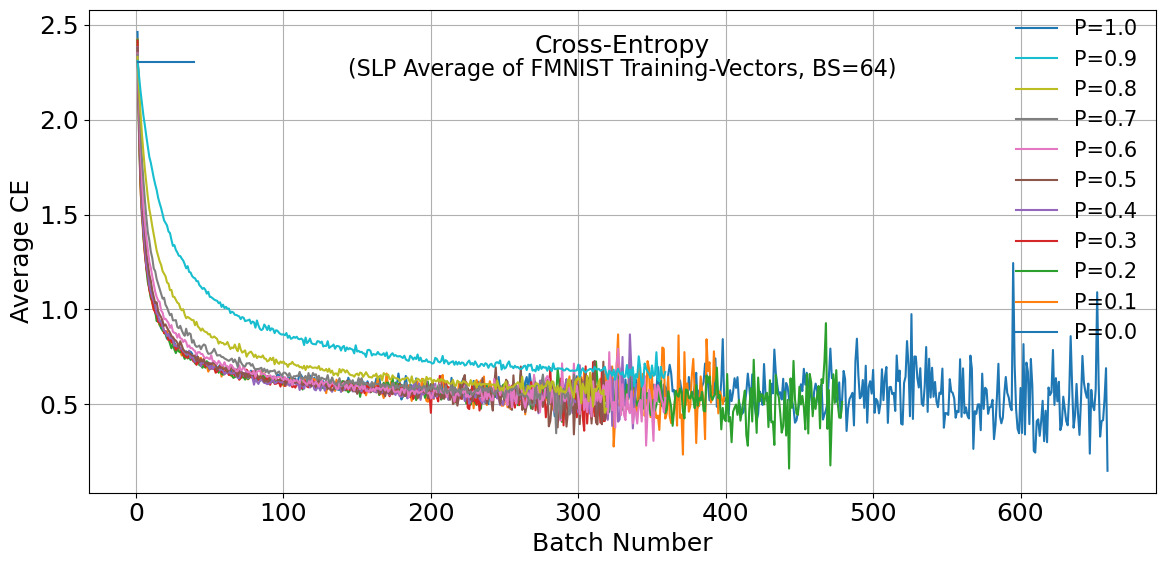

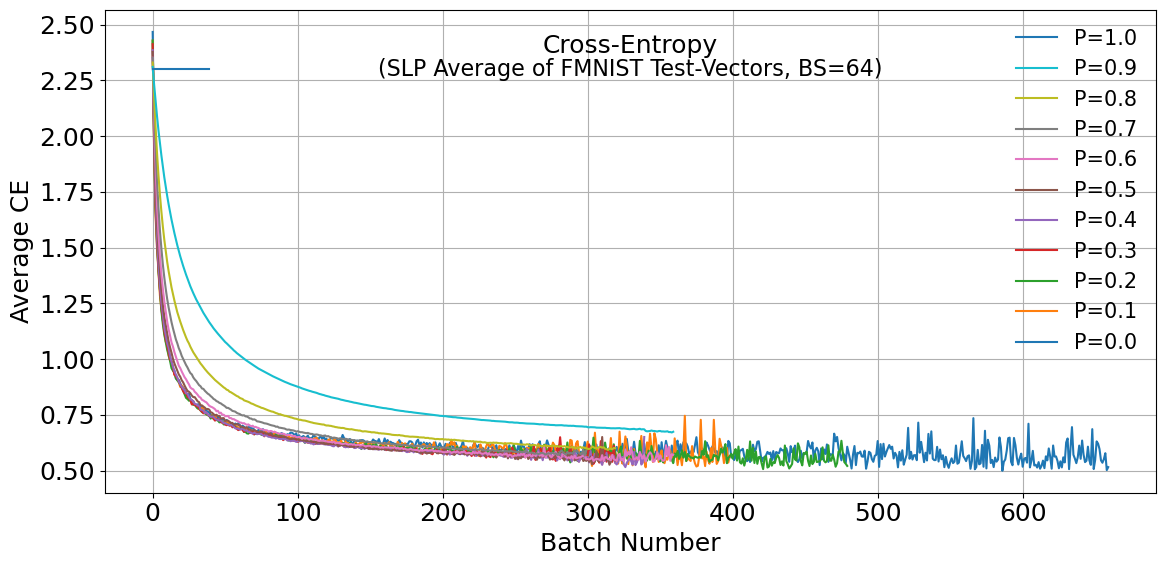

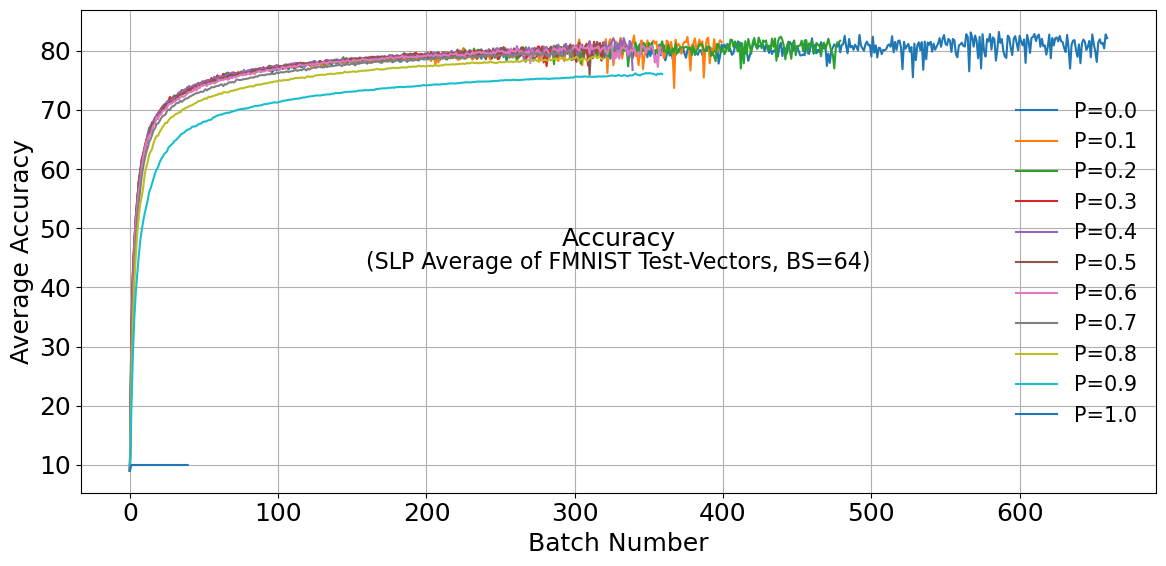

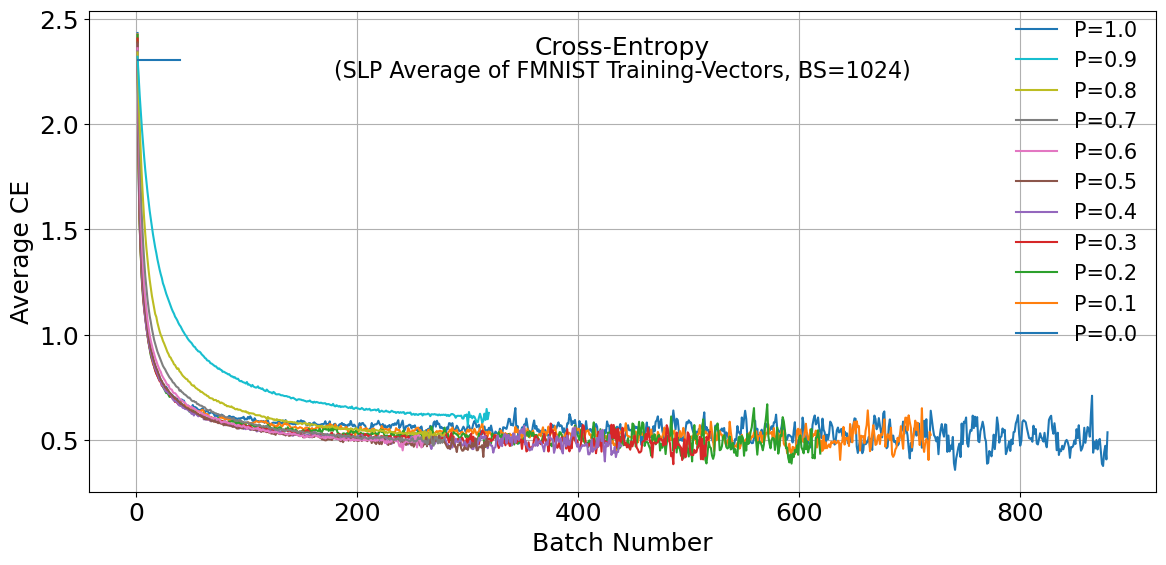

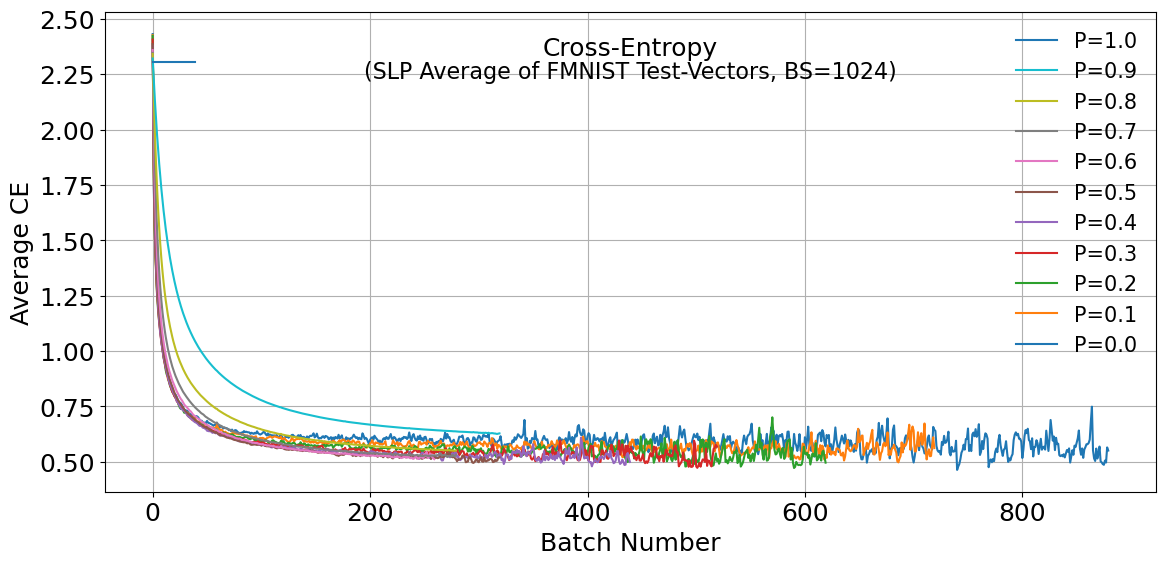

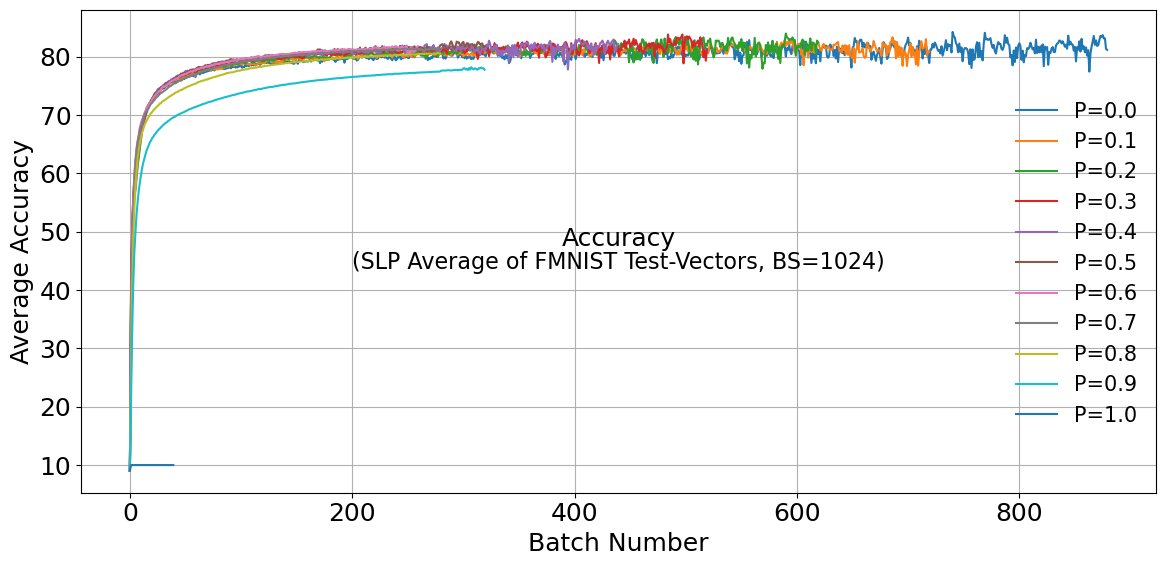

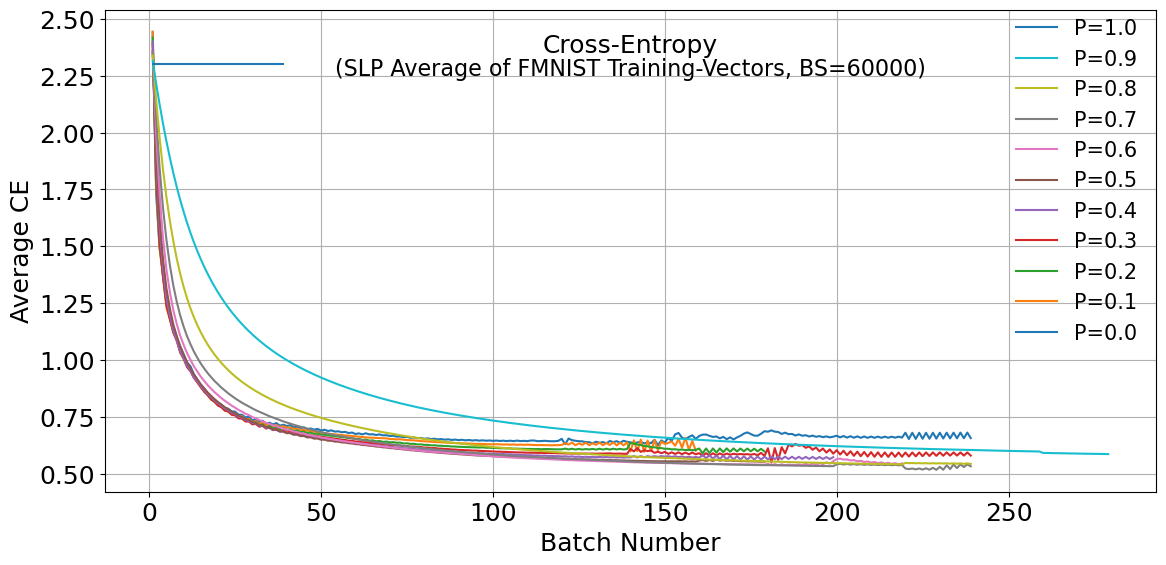

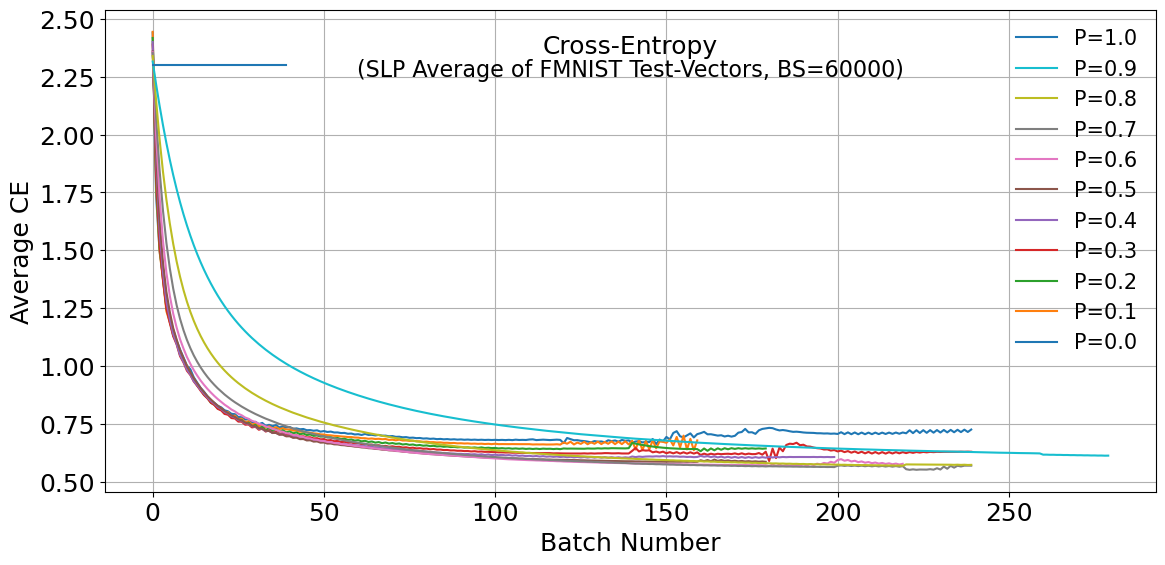

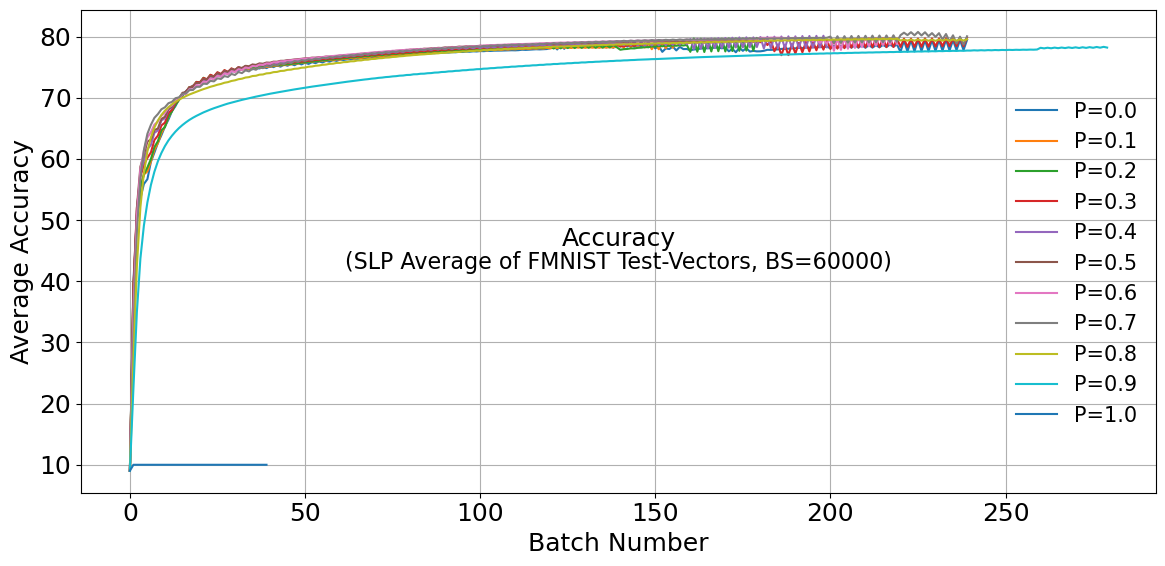

In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
# BASE_DIR = r"Convolution/Convolutional/Convolutional-MNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
FILE_PATTERN = "slp_{:.1f}_{}_run_*"

BATCH_SIZES = [64, 1024, 60000]

# =========================
# STYLE (Nature-like)
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15
})

# =========================
# LOOP OVER BATCH SIZES
# =========================
for bs in BATCH_SIZES:
    all_avg_dfs = {}

    for p in [round(x*0.1,1) for x in range(0,11)]:
        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        pattern = FILE_PATTERN.format(p, bs)
        files = glob.glob(os.path.join(folder, pattern))

        if not files:
            print(f"[WARNING] No files found for pruning {p} and batch size {bs}")
            continue

        # =========================
        # LOAD ALL RUNS
        # =========================
        dfs = []
        for f in files:
            df = pd.read_csv(f, sep=r"\s+")
            df.columns = df.columns.str.strip()

            df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
            df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
            df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

            dfs.append(df)

        all_runs = pd.concat(dfs, ignore_index=True)

        # =========================
        # GROUP + AVERAGE
        # =========================
        avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Num_Runs=("CE_TEST", "count")
        )

        # =========================
        # SAVE CSV
        # =========================
        out_csv = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")
        avg_df.to_csv(out_csv, index=False)

        all_avg_dfs[p] = avg_df

    # =========================
    # COMBINED PLOT (CE_Train)
    # =========================
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():
        plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Train"], label=f"P={p}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")

    plt.text(0.50, 0.95, "Cross-Entropy", transform=plt.gca().transAxes, va='top', ha ='center')
    plt.text(0.50, 0.90, f"(SLP Average of FMNIST Training-Vectors, BS={bs})", ha ='center',
             fontsize=16, transform=plt.gca().transAxes, va='top')

    handles, labels = plt.gca().get_legend_handles_labels()
    # plt.legend(handles[::-1], labels[::-1], loc="upper right", frameon=False)
    plt.legend(handles[::-1], labels[::-1],
           loc="upper right",
           bbox_to_anchor=(1.0, 1.02),
           frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"CE_Train_Avg_SLP_FMNIST_BS_{bs}.png", bbox_inches='tight', dpi=300)
    plt.show()

    # =========================
    # COMBINED PLOT (CE_Test)
    # =========================
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():
        plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"], label=f"P={p}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")

    plt.text(0.50, 0.95, "Cross-Entropy", transform=plt.gca().transAxes, ha = 'center', va='top')
    plt.text(0.50, 0.90, f"(SLP Average of FMNIST Test-Vectors, BS={bs})",ha = 'center',
             fontsize=16, transform=plt.gca().transAxes, va='top')

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[::-1], labels[::-1], loc="upper right", frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"CE_Test_Avg_SLP_FMNIST_BS_{bs}.png", bbox_inches='tight', dpi=300)
    plt.show()



    # =========================
    # COMBINED PLOT (Accuracy)
    # =========================
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():
        plt.plot(avg_df["Batch_Number"], avg_df["Avg_Accuracy"], label=f"P={p}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average Accuracy")

    plt.text(0.50, 0.55, "Accuracy", transform=plt.gca().transAxes,ha= 'center', va='top')
    plt.text(0.50, 0.50, f"(SLP Average of FMNIST Test-Vectors, BS={bs})", ha= 'center',
             fontsize=16, transform=plt.gca().transAxes, va='top')

    # this is to invert the labels
    # handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
        # handles[::-1], labels[::-1],
        
        loc="lower right", frameon=False,
    bbox_to_anchor=(1.0, 0.1))

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Accuracy_Avg_SLP_FMNIST_BS_{bs}.png", bbox_inches='tight', dpi=300)
    plt.show()

    

